# Inspect Data and Label Classes

This notebook inspects downloaded COCO datasets and lists label classes and basic stats.

In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

In [2]:
DATA_ROOTS = [Path('/work/data'), Path('/work/scripts/data')]
COCO_PATTERN = '**/_annotations.coco.json'

def find_coco_files() -> list[Path]:
    files: list[Path] = []
    for root in DATA_ROOTS:
        if root.exists():
            files.extend(root.glob(COCO_PATTERN))
    return sorted(set(files))

coco_files = find_coco_files()
print(f'Found {len(coco_files)} COCO annotation files:')
for p in coco_files:
    print('-', p)

Found 6 COCO annotation files:
- /work/scripts/data/classification/test/_annotations.coco.json
- /work/scripts/data/classification/train/_annotations.coco.json
- /work/scripts/data/classification/valid/_annotations.coco.json
- /work/scripts/data/detection/test/_annotations.coco.json
- /work/scripts/data/detection/train/_annotations.coco.json
- /work/scripts/data/detection/valid/_annotations.coco.json


In [3]:
def load_coco(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def summarize_categories(coco: dict) -> tuple[dict[int, str], Counter]:
    categories = coco.get('categories', [])
    annotations = coco.get('annotations', [])

    id_to_name = {int(c['id']): str(c.get('name', '')) for c in categories if 'id' in c}
    cat_counts = Counter()

    for ann in annotations:
        cat_id = ann.get('category_id')
        if isinstance(cat_id, int):
            cat_counts[cat_id] += 1

    return id_to_name, cat_counts

In [4]:
for path in coco_files:
    coco = load_coco(path)
    images = coco.get('images', [])
    anns = coco.get('annotations', [])
    id_to_name, cat_counts = summarize_categories(coco)

    print('\n' + '=' * 110)
    print(f'FILE: {path}')
    print(f'Images: {len(images)} | Annotations: {len(anns)} | Classes: {len(id_to_name)}')
    print('-' * 110)

    for cat_id, cat_name in sorted(id_to_name.items(), key=lambda x: x[0]):
        print(f'id={cat_id:>3} | name={cat_name:<30} | annotations={cat_counts.get(cat_id, 0)}')


FILE: /work/scripts/data/classification/test/_annotations.coco.json
Images: 1342 | Annotations: 18804 | Classes: 80
--------------------------------------------------------------------------------------------------------------
id=  0 | name=see                            | annotations=0
id=  1 | name=3M ESPE Implant                | annotations=661
id=  2 | name=47                             | annotations=17
id=  3 | name=48                             | annotations=1
id=  4 | name=49                             | annotations=1
id=  5 | name=50                             | annotations=0
id=  6 | name=51                             | annotations=10
id=  7 | name=52                             | annotations=2922
id=  8 | name=53                             | annotations=0
id=  9 | name=54                             | annotations=11
id= 10 | name=55                             | annotations=8
id= 11 | name=56                             | annotations=14
id= 12 | name=57               

In [5]:
# Optional: show a compact union of class names across all COCO files
all_class_names = set()

for path in coco_files:
    coco = load_coco(path)
    categories = coco.get('categories', [])
    for c in categories:
        all_class_names.add(str(c.get('name', '')))

print(f'Total unique class names across files: {len(all_class_names)}')
for name in sorted(all_class_names):
    print('-', name)

Total unique class names across files: 151
- 1
- 10
- 11
- 12
- 13
- 14
- 15
- 16
- 17
- 18
- 19
- 2
- 20
- 21
- 22
- 23
- 24
- 25
- 26
- 27
- 28
- 29
- 3
- 30
- 31
- 32
- 3M ESPE
- 3M ESPE Implant
- 4
- 47
- 48
- 49
- 5
- 50
- 51
- 52
- 53
- 54
- 55
- 56
- 57
- 58
- 59
- 6
- 60
- 61
- 62
- 63
- 64
- 65
- 66
- 67
- 68
- 69
- 7
- 70
- 71
- 72
- 73
- 74
- 75
- 76
- 77
- 78
- 8
- 9
- AGS Medikal
- AGS Medikal Implant
- AMerOss
- AMerOss Implant
- Amalgam filling
- Anthogyr
- Anthogyr Implant
- Bicon
- Bicon Implant
- BioHorizons
- BioHorizons Implant
- BioLife
- BioLife Implant
- Biomet 3i
- Biomet 3i Implant
- Blue Sky Bio
- Blue Sky Bio Implant
- Camlog
- Camlog Implant
- Caries
- Composite filling
- Cowellmedi
- Cowellmedi Implant
- Crown
- DENTSPLY
- DENTSPLY Implant
- Dentatus
- Dentatus Implant
- Dentis
- Dentis Implant
- Dentium
- Dentium Implant
- Euroteknika
- Euroteknika Implant
- Filling
- Frontier
- Frontier Implant
- Hiossen
- Hiossen Implant
- Implant
- Implant Direct
- Keys

## Find healthy teeth labels and annotations

This section detects classes that look like healthy teeth and counts their annotations (with valid bounding boxes) in each COCO file.

In [6]:
HEALTHY_KEYWORDS = (
    'healthy',
    'normal',
    'sound',
    'intact',
    'no caries',
    'caries free',
    'caries-free',
    'caries_free',
    'non-caries',
    'non caries',
    'without caries',
)

def normalize_label(label: str) -> str:
    return ' '.join(str(label).lower().replace('_', ' ').replace('-', ' ').split())

def looks_healthy(label: str) -> bool:
    text = normalize_label(label)
    return any(k in text for k in HEALTHY_KEYWORDS)

def valid_bbox(ann: dict) -> bool:
    bbox = ann.get('bbox')
    if not isinstance(bbox, list) or len(bbox) != 4:
        return False
    try:
        return float(bbox[2]) > 0 and float(bbox[3]) > 0
    except (TypeError, ValueError):
        return False

overall_healthy_ann_count = 0
files_with_healthy = 0

for path in coco_files:
    coco = load_coco(path)
    categories = coco.get('categories', [])
    annotations = coco.get('annotations', [])

    id_to_name = {int(c['id']): str(c.get('name', '')) for c in categories if 'id' in c}
    healthy_ids = {cid for cid, name in id_to_name.items() if looks_healthy(name)}
    healthy_names = sorted({id_to_name[cid] for cid in healthy_ids})

    healthy_anns = [
        ann for ann in annotations
        if ann.get('category_id') in healthy_ids and valid_bbox(ann)
    ]

    healthy_count = len(healthy_anns)
    overall_healthy_ann_count += healthy_count
    if healthy_count > 0:
        files_with_healthy += 1

    print('\n' + '=' * 110)
    print('FILE:', path)
    print('Healthy-like classes found:', healthy_names if healthy_names else 'None')
    print('Healthy annotations with valid bbox:', healthy_count)
    if healthy_anns:
        print('Example healthy bbox:', healthy_anns[0].get('bbox'))

print('\n' + '=' * 110)
print('SUMMARY')
print('Files scanned:', len(coco_files))
print('Files with healthy annotations:', files_with_healthy)
print('Total healthy annotations with valid bbox:', overall_healthy_ann_count)


FILE: /work/scripts/data/classification/test/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

FILE: /work/scripts/data/classification/train/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

FILE: /work/scripts/data/classification/valid/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

FILE: /work/scripts/data/detection/test/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

FILE: /work/scripts/data/detection/train/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

FILE: /work/scripts/data/detection/valid/_annotations.coco.json
Healthy-like classes found: None
Healthy annotations with valid bbox: 0

SUMMARY
Files scanned: 6
Files with healthy annotations: 0
Total healthy annotations with valid bbox: 0


In [7]:
# Helper: inspect class names that contain diagnostic keywords.
KEYWORD_FILTERS = ('caries', 'health', 'healthy', 'normal', 'sound', 'intact')

for path in coco_files:
    coco = load_coco(path)
    names = sorted(str(c.get('name', '')) for c in coco.get('categories', []))
    matched = [n for n in names if any(k in n.lower() for k in KEYWORD_FILTERS)]

    print('\n' + '=' * 110)
    print('FILE:', path)
    if matched:
        print('Keyword-matching class names:')
        for m in matched:
            print('-', m)
    else:
        print('No class names match:', KEYWORD_FILTERS)


FILE: /work/scripts/data/classification/test/_annotations.coco.json
Keyword-matching class names:
- Caries

FILE: /work/scripts/data/classification/train/_annotations.coco.json
Keyword-matching class names:
- Caries

FILE: /work/scripts/data/classification/valid/_annotations.coco.json
Keyword-matching class names:
- Caries

FILE: /work/scripts/data/detection/test/_annotations.coco.json
Keyword-matching class names:
- Caries

FILE: /work/scripts/data/detection/train/_annotations.coco.json
Keyword-matching class names:
- Caries

FILE: /work/scripts/data/detection/valid/_annotations.coco.json
Keyword-matching class names:
- Caries


## Detection-focused inspection with original classes preserved

This section inspects detection annotations while keeping all original classes.
It also proposes healthy tooth candidates using zero/near-zero overlap with caries boxes.

In [8]:
from collections import defaultdict
import pandas as pd

detection_files = [p for p in coco_files if '/detection/' in str(p)]
print('Detection COCO files:', len(detection_files))
for p in detection_files:
    print('-', p)

Detection COCO files: 3
- /work/scripts/data/detection/test/_annotations.coco.json
- /work/scripts/data/detection/train/_annotations.coco.json
- /work/scripts/data/detection/valid/_annotations.coco.json


In [9]:
def coco_to_xyxy(bbox: list[float]) -> list[float]:
    x, y, w, h = bbox
    return [float(x), float(y), float(x + w), float(y + h)]

def box_area(box: list[float]) -> float:
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def box_intersection_area(a: list[float], b: list[float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)
    return max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)

def overlap_over_tooth(tooth_box: list[float], other_box: list[float]) -> float:
    area = box_area(tooth_box)
    if area <= 0.0:
        return 0.0
    return box_intersection_area(tooth_box, other_box) / area

def is_tooth_number_class(name: str) -> bool:
    return str(name).strip().isdigit()

def is_caries_class(name: str) -> bool:
    return 'caries' in str(name).lower()

In [10]:
rows = []
for path in detection_files:
    coco = load_coco(path)
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}
    counts = Counter()
    for ann in coco.get('annotations', []):
        cid = ann.get('category_id')
        if isinstance(cid, int):
            counts[cid] += 1

    split = path.parent.name
    for cid, name in sorted(cats.items(), key=lambda x: x[0]):
        rows.append({
            'split': split,
            'category_id': cid,
            'class_name': name,
            'is_tooth_number': is_tooth_number_class(name),
            'is_caries': is_caries_class(name),
            'annotation_count': counts.get(cid, 0),
        })

class_df = pd.DataFrame(rows).sort_values(['split', 'category_id']).reset_index(drop=True)
print('All original detection classes with counts:')
display(class_df)

All original detection classes with counts:


,split,category_id,class_name,is_tooth_number,is_caries,annotation_count
0,test,0,im-t,False,False,0
1,test,1,1,True,False,630
2,test,2,10,True,False,154
3,test,3,11,True,False,141
4,test,4,12,True,False,158
...,...,...,...,...,...,...
250,valid,80,Straumann,False,False,3
251,valid,81,Straumann ITI,False,False,1
252,valid,82,Titan Implants,False,False,0
253,valid,83,Zimmer,False,False,7


In [11]:
candidate_rows = []
overlap_threshold = 0.01

for path in detection_files:
    coco = load_coco(path)
    split = path.parent.name

    images = {int(i['id']): i for i in coco.get('images', [])}
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}

    ann_by_image: dict[int, list[dict]] = defaultdict(list)
    for ann in coco.get('annotations', []):
        image_id = int(ann['image_id'])
        ann_by_image[image_id].append(ann)

    caries_ids = {cid for cid, name in cats.items() if is_caries_class(name)}
    tooth_ids = {cid for cid, name in cats.items() if is_tooth_number_class(name)}

    for image_id, anns in ann_by_image.items():
        caries_boxes = []
        for ann in anns:
            cid = ann.get('category_id')
            bbox = ann.get('bbox')
            if cid in caries_ids and isinstance(bbox, list) and len(bbox) == 4:
                caries_boxes.append(coco_to_xyxy(bbox))

        for ann in anns:
            cid = ann.get('category_id')
            bbox = ann.get('bbox')
            if cid not in tooth_ids:
                continue
            if not (isinstance(bbox, list) and len(bbox) == 4):
                continue

            tooth_box = coco_to_xyxy(bbox)
            max_overlap = 0.0
            for cb in caries_boxes:
                max_overlap = max(max_overlap, overlap_over_tooth(tooth_box, cb))

            img = images.get(image_id, {})
            candidate_rows.append({
                'split': split,
                'image_id': image_id,
                'file_name': img.get('file_name', ''),
                'tooth_category_id': int(cid),
                'tooth_class_name': cats.get(int(cid), ''),
                'tooth_bbox_xywh': bbox,
                'max_caries_overlap_over_tooth': float(max_overlap),
                'proposed_status': 'healthy_candidate' if max_overlap < overlap_threshold else 'caries_overlap',
            })

cand_df = pd.DataFrame(candidate_rows)
print('Tooth instances analyzed:', len(cand_df))
display(cand_df.head(20))

Tooth instances analyzed: 80182


,split,image_id,file_name,tooth_category_id,tooth_class_name,tooth_bbox_xywh,max_caries_overlap_over_tooth,proposed_status
0,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,7,15,"[481, 178, 43.558, 135.879]",0.0,healthy_candidate
1,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,8,16,"[498, 157, 50.487, 121.407]",0.0,healthy_candidate
2,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,10,18,"[480, 330, 58.902, 141.508]",0.0,healthy_candidate
3,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,9,17,"[521, 308, 52.962, 118.995]",0.0,healthy_candidate
4,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,26,32,"[93, 310, 69.296, 71.558]",0.0,healthy_candidate
5,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,25,31,"[146, 325, 53.952, 145.528]",0.0,healthy_candidate
6,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,12,2,"[155, 161, 48.012, 137.487]",0.0,healthy_candidate
7,test,0,3683190000-jpg_png_jpg.rf.d94e189822f1af7cd5e9...,1,1,"[135, 158, 40.093, 105.327]",0.0,healthy_candidate
8,test,2,4049110000-jpg_png_jpg.rf.4ae357fd4745ddd46a7b...,12,2,"[197, 233, 23.696, 96.78]",0.0,healthy_candidate
9,test,2,4049110000-jpg_png_jpg.rf.4ae357fd4745ddd46a7b...,1,1,"[180, 231, 28.913, 78.049]",0.0,healthy_candidate


In [12]:
summary_df = (
    cand_df.groupby(['split', 'tooth_class_name', 'proposed_status'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values(['split', 'tooth_class_name', 'proposed_status'])
    .reset_index(drop=True)
)
display(summary_df)

print('Overall proposed status counts:')
display(cand_df['proposed_status'].value_counts(dropna=False))

,split,tooth_class_name,proposed_status,count
0,test,1,healthy_candidate,630
1,test,10,healthy_candidate,154
2,test,11,healthy_candidate,141
3,test,12,healthy_candidate,158
4,test,13,healthy_candidate,155
...,...,...,...,...
91,valid,5,healthy_candidate,502
92,valid,6,healthy_candidate,513
93,valid,7,healthy_candidate,522
94,valid,8,healthy_candidate,506


Overall proposed status counts:


proposed_status
healthy_candidate    80182
Name: count, dtype: int64

In [13]:
healthy_pool = cand_df[cand_df['proposed_status'] == 'healthy_candidate'].copy()
review_n = min(500, len(healthy_pool))
review_df = healthy_pool.sample(n=review_n, random_state=42) if review_n > 0 else healthy_pool.copy()

review_df['review_label'] = ''  # healthy / uncertain / caries
review_df['review_notes'] = ''

print('Review set rows:', len(review_df))
display(review_df.head(30))

Review set rows: 500


,split,image_id,file_name,tooth_category_id,tooth_class_name,tooth_bbox_xywh,max_caries_overlap_over_tooth,proposed_status,review_label,review_notes
6144,test,850,4026290000-jpg_png_jpg.rf.467ecfb9436bd6fa8c93...,10,18,"[439, 340, 40.509, 100.93]",0.0,healthy_candidate,,
62899,valid,181,cate8-00094_jpg.rf.c48f86d5930dd4082da3e9be4d1...,14,21,"[380, 361, 27.644, 154.463]",0.0,healthy_candidate,,
63635,valid,245,cate8-00025_jpg.rf.74215f28b7807cfc6edbada036f...,9,17,"[497, 291, 54.967, 113.576]",0.0,healthy_candidate,,
25969,train,2031,4091940000-jpg_png_jpg.rf.e9a1f88ab9ef1fe05138...,9,17,"[455, 322, 41.087, 69.129]",0.0,healthy_candidate,,
67798,valid,521,cate4-00010_jpg.rf.7d8ab61438a1b39ed8e9757ecc8...,29,5,"[211, 189, 28.287, 147.081]",0.0,healthy_candidate,,
73051,valid,873,cate1-00016_jpg.rf.e4a0665c01e6e9579e734631271...,24,30,"[152, 346, 66.861, 133.452]",0.0,healthy_candidate,,
29053,train,2433,3795520000-jpg_png_jpg.rf.d5ae3d53c28626fdbac0...,8,16,"[432, 226, 29.646, 72.558]",0.0,healthy_candidate,,
74220,valid,956,cate8-00134_jpg.rf.1995fc300402a0cad2a11b20846...,33,9,"[332, 193, 24.43, 156.735]",0.0,healthy_candidate,,
13495,train,408,cate4-00001_jpg.rf.800e2919dbe9a7c6e8aac82c295...,6,14,"[379, 372, 23.466, 116.415]",0.0,healthy_candidate,,
8781,test,1181,cate4-00013_jpg.rf.9a4487cfc1167fdffabdca9198c...,4,12,"[130, 155, 44.36, 152.192]",0.0,healthy_candidate,,


In [14]:
# Diagnostic: check whether caries boxes exist and whether any overlap was found at all.
diag_rows = []
for path in detection_files:
    coco = load_coco(path)
    split = path.parent.name
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}
    caries_ids = {cid for cid, name in cats.items() if is_caries_class(name)}
    anns = coco.get('annotations', [])

    caries_ann_count = sum(1 for a in anns if a.get('category_id') in caries_ids)
    max_overlap = cand_df.loc[cand_df['split'] == split, 'max_caries_overlap_over_tooth'].max()
    mean_overlap = cand_df.loc[cand_df['split'] == split, 'max_caries_overlap_over_tooth'].mean()

    diag_rows.append({
        'split': split,
        'caries_category_ids': sorted(caries_ids),
        'caries_annotation_count': caries_ann_count,
        'max_detected_overlap': float(max_overlap) if pd.notna(max_overlap) else 0.0,
        'mean_detected_overlap': float(mean_overlap) if pd.notna(mean_overlap) else 0.0,
    })

diag_df = pd.DataFrame(diag_rows).sort_values('split').reset_index(drop=True)
display(diag_df)

,split,caries_category_ids,caries_annotation_count,max_detected_overlap,mean_detected_overlap
0,test,[44],582,0.0,0.0
1,train,[44],2450,0.0,0.0
2,valid,[44],404,0.0,0.0


## Cross-dataset image mapping check (detection vs classification)

This section tests whether detection and classification annotations reference the same source images via file names, stems, and split-aware joins.

In [15]:
classification_files = [p for p in coco_files if '/classification/' in str(p)]
detection_files = [p for p in coco_files if '/detection/' in str(p)]

print('Classification COCO files:', len(classification_files))
for p in classification_files:
    print('-', p)
print('Detection COCO files:', len(detection_files))
for p in detection_files:
    print('-', p)

def extract_image_table(files: list[Path], source: str) -> pd.DataFrame:
    rows = []
    for path in files:
        coco = load_coco(path)
        split = path.parent.name
        for img in coco.get('images', []):
            file_name = str(img.get('file_name', ''))
            rows.append({
                'source': source,
                'split': split,
                'file_name': file_name,
                'file_stem': Path(file_name).stem.lower(),
                'image_id': int(img.get('id', -1)),
                'width': int(img.get('width', -1)),
                'height': int(img.get('height', -1)),
            })
    return pd.DataFrame(rows)

det_img_df = extract_image_table(detection_files, source='detection')
cls_img_df = extract_image_table(classification_files, source='classification')

print('Detection images:', len(det_img_df), '| unique file names:', det_img_df['file_name'].nunique())
print('Classification images:', len(cls_img_df), '| unique file names:', cls_img_df['file_name'].nunique())

Classification COCO files: 3
- /work/scripts/data/classification/test/_annotations.coco.json
- /work/scripts/data/classification/train/_annotations.coco.json
- /work/scripts/data/classification/valid/_annotations.coco.json
Detection COCO files: 3
- /work/scripts/data/detection/test/_annotations.coco.json
- /work/scripts/data/detection/train/_annotations.coco.json
- /work/scripts/data/detection/valid/_annotations.coco.json
Detection images: 9374 | unique file names: 9374
Classification images: 8947 | unique file names: 8947


In [16]:
# 1) Exact file_name + split mapping
exact_split_map = det_img_df.merge(
    cls_img_df,
    on=['split', 'file_name'],
    suffixes=('_det', '_cls')
)

print('Exact mapping on [split, file_name]:', len(exact_split_map))
if len(exact_split_map) > 0:
    exact_split_map['same_dimensions'] = (
        (exact_split_map['width_det'] == exact_split_map['width_cls'])
        & (exact_split_map['height_det'] == exact_split_map['height_cls'])
    )
    print('Exact split-mapped rows with same dimensions:', int(exact_split_map['same_dimensions'].sum()))
    display(exact_split_map.head(20))

# 2) Exact file_name mapping ignoring split
exact_name_map = det_img_df.merge(
    cls_img_df,
    on=['file_name'],
    suffixes=('_det', '_cls')
)

print('Exact mapping on [file_name] (split-agnostic):', len(exact_name_map))
if len(exact_name_map) > 0:
    exact_name_map['same_dimensions'] = (
        (exact_name_map['width_det'] == exact_name_map['width_cls'])
        & (exact_name_map['height_det'] == exact_name_map['height_cls'])
    )
    print('Exact name-mapped rows with same dimensions:', int(exact_name_map['same_dimensions'].sum()))
    display(exact_name_map[['split_det', 'split_cls', 'file_name', 'width_det', 'height_det', 'width_cls', 'height_cls', 'same_dimensions']].head(20))

# 3) Stem mapping (fallback when folders/extensions differ)
stem_map = det_img_df.merge(
    cls_img_df,
    on=['file_stem'],
    suffixes=('_det', '_cls')
)

print('Stem mapping on [file_stem]:', len(stem_map))
if len(stem_map) > 0:
    stem_map['same_dimensions'] = (
        (stem_map['width_det'] == stem_map['width_cls'])
        & (stem_map['height_det'] == stem_map['height_cls'])
    )
    print('Stem-mapped rows with same dimensions:', int(stem_map['same_dimensions'].sum()))
    display(stem_map[['split_det', 'split_cls', 'file_name_det', 'file_name_cls', 'file_stem', 'same_dimensions']].head(20))

Exact mapping on [split, file_name]: 0
Exact mapping on [file_name] (split-agnostic): 0
Stem mapping on [file_stem]: 0


In [17]:
# Coverage diagnostics for unmatched images
det_names = set(det_img_df['file_name'].tolist())
cls_names = set(cls_img_df['file_name'].tolist())

det_only_names = det_names - cls_names
cls_only_names = cls_names - det_names

print('Unique detection file names not in classification:', len(det_only_names))
print('Unique classification file names not in detection:', len(cls_only_names))

if len(det_only_names) > 0:
    print('Sample detection-only names:')
    for name in sorted(list(det_only_names))[:15]:
        print('-', name)

if len(cls_only_names) > 0:
    print('Sample classification-only names:')
    for name in sorted(list(cls_only_names))[:15]:
        print('-', name)

Unique detection file names not in classification: 9374
Unique classification file names not in detection: 8947
Sample detection-only names:
- 000dc27f-NAJIB_MARDANLOO_MASUME_2020-07-12185357_jpg.rf.b44e8be6cb6cd2d50f310034eafb0e72.jpg
- 003e5f80-MOHAMADI_ATEFEH_2020-06-01173808_jpg.rf.b37f3aab45137c77b855d2a88ef79884.jpg
- 0043783e-Asiadar_Leila_2022-06-12141026_jpg.rf.392164e9f4d1a94b74b89282945984e8.jpg
- 00cf39c1-Karaptiyan_Robert_50yo_13032021_185908_jpg.rf.57ff2718914ee1f85edafb9d1444e91e.jpg
- 01b0dd74-Gazavandi_Neda_2022-05-14190158_jpg.rf.58aeba4c86ac354e3ed448d02ee52fde.jpg
- 026e78e8-GHASEMI_MASOMEH_2020-06-15134512_jpg.rf.1a0a7380b94a5e193a4f1bed004f6cbf.jpg
- 02b46381-Rezaee_Maryam_2022-06-12141528_jpg.rf.ab23a4a32803ec6e18f85358e5a02ed3.jpg
- 033516be-SAFAPOOR_MOHAMMADHOSEIN_2020-07-21162045_jpg.rf.5ccb281bf9e153d39a68f92da277e440.jpg
- 0424a401-Edrispour_Seyedekhadijeh_2022-05-14193301_jpg.rf.351222221e0a0154e94f84cdf1d96064.jpg
- 045b3b84-PIRI_NAJME_2020-02-18184406_jpg

## Classification dataset opportunities (original classes preserved)

Since detection and classification image sets do not map by file name/stem, this section mines healthy opportunities directly from classification annotations while preserving original class labels.

In [18]:
classification_files = [p for p in coco_files if '/classification/' in str(p)]

cls_rows = []
for path in classification_files:
    coco = load_coco(path)
    split = path.parent.name
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}
    counts = Counter()
    for ann in coco.get('annotations', []):
        cid = ann.get('category_id')
        if isinstance(cid, int):
            counts[cid] += 1

    for cid, name in sorted(cats.items(), key=lambda x: x[0]):
        cls_rows.append({
            'split': split,
            'category_id': cid,
            'class_name': name,
            'is_tooth_number': is_tooth_number_class(name),
            'is_caries': is_caries_class(name),
            'annotation_count': counts.get(cid, 0),
        })

cls_class_df = pd.DataFrame(cls_rows).sort_values(['split', 'category_id']).reset_index(drop=True)
print('Classification original classes with counts:')
display(cls_class_df)

Classification original classes with counts:


,split,category_id,class_name,is_tooth_number,is_caries,annotation_count
0,test,0,see,False,False,0
1,test,1,3M ESPE Implant,False,False,661
2,test,2,47,True,False,17
3,test,3,48,True,False,1
4,test,4,49,True,False,1
...,...,...,...,...,...,...
235,valid,75,Root canal obturation,False,False,34
236,valid,76,Sterngold Implant,False,False,407
237,valid,77,Straumann Implant,False,False,168
238,valid,78,Titan Implant Implant,False,False,36


In [19]:
cls_candidate_rows = []
cls_overlap_threshold = 0.01

for path in classification_files:
    coco = load_coco(path)
    split = path.parent.name
    images = {int(i['id']): i for i in coco.get('images', [])}
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}

    ann_by_image: dict[int, list[dict]] = defaultdict(list)
    for ann in coco.get('annotations', []):
        image_id = int(ann['image_id'])
        ann_by_image[image_id].append(ann)

    caries_ids = {cid for cid, name in cats.items() if is_caries_class(name)}
    tooth_ids = {cid for cid, name in cats.items() if is_tooth_number_class(name)}

    for image_id, anns in ann_by_image.items():
        caries_boxes = []
        for ann in anns:
            cid = ann.get('category_id')
            bbox = ann.get('bbox')
            if cid in caries_ids and isinstance(bbox, list) and len(bbox) == 4:
                caries_boxes.append(coco_to_xyxy(bbox))

        tooth_anns = []
        for ann in anns:
            cid = ann.get('category_id')
            bbox = ann.get('bbox')
            if cid in tooth_ids and isinstance(bbox, list) and len(bbox) == 4:
                tooth_anns.append(ann)

        has_any_caries_in_image = len(caries_boxes) > 0

        for ann in tooth_anns:
            cid = int(ann['category_id'])
            bbox = ann['bbox']
            tooth_box = coco_to_xyxy(bbox)
            max_overlap = 0.0
            for cb in caries_boxes:
                max_overlap = max(max_overlap, overlap_over_tooth(tooth_box, cb))

            if not has_any_caries_in_image:
                proposed_status = 'healthy_from_caries_free_image'
            elif max_overlap < cls_overlap_threshold:
                proposed_status = 'healthy_candidate_zero_overlap'
            else:
                proposed_status = 'uncertain_has_overlap'

            img = images.get(image_id, {})
            cls_candidate_rows.append({
                'split': split,
                'image_id': image_id,
                'file_name': img.get('file_name', ''),
                'tooth_category_id': cid,
                'tooth_class_name': cats.get(cid, ''),
                'tooth_bbox_xywh': bbox,
                'has_any_caries_in_image': has_any_caries_in_image,
                'max_caries_overlap_over_tooth': float(max_overlap),
                'proposed_status': proposed_status,
            })

cls_cand_df = pd.DataFrame(cls_candidate_rows)
print('Classification tooth instances analyzed:', len(cls_cand_df))
display(cls_cand_df.head(20))

Classification tooth instances analyzed: 32354


,split,image_id,file_name,tooth_category_id,tooth_class_name,tooth_bbox_xywh,has_any_caries_in_image,max_caries_overlap_over_tooth,proposed_status
0,test,0,3986700000-jpg_png_jpg.rf.043d5a90388a9b8d188f...,7,52,"[202, 325, 31.087, 51.289]",True,0.000000,healthy_candidate_zero_overlap
1,test,0,3986700000-jpg_png_jpg.rf.043d5a90388a9b8d188f...,7,52,"[406, 330, 38.478, 55.749]",True,0.000000,healthy_candidate_zero_overlap
2,test,0,3986700000-jpg_png_jpg.rf.043d5a90388a9b8d188f...,28,73,"[608, 557, 5, 10]",True,0.000000,healthy_candidate_zero_overlap
3,test,2,3824860000-jpg_png_jpg.rf.270a234e170d1b1d490a...,28,73,"[599, 559, 15, 41]",True,0.000000,healthy_candidate_zero_overlap
4,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[172, 337, 36.436, 46.977]",True,0.000000,healthy_candidate_zero_overlap
5,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[205, 353, 36.209, 49.767]",True,0.000000,healthy_candidate_zero_overlap
6,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[254, 380, 22.405, 37.674]",True,0.000000,healthy_candidate_zero_overlap
7,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[385, 387, 21.499, 44.186]",True,0.000000,healthy_candidate_zero_overlap
8,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[402, 372, 34.173, 50.233]",True,0.000000,healthy_candidate_zero_overlap
9,test,5,3011650000-jpg_png_jpg.rf.20fa8ca632ccdac90b89...,7,52,"[431, 352, 36.209, 45.116]",True,0.000000,healthy_candidate_zero_overlap


In [20]:
cls_summary_df = (
    cls_cand_df.groupby(['split', 'tooth_class_name', 'proposed_status'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values(['split', 'tooth_class_name', 'proposed_status'])
    .reset_index(drop=True)
)
display(cls_summary_df)

print('Classification proposed status counts:')
display(cls_cand_df['proposed_status'].value_counts(dropna=False))

cls_review_pool = cls_cand_df[
    cls_cand_df['proposed_status'].isin(['healthy_from_caries_free_image', 'healthy_candidate_zero_overlap'])
]
cls_review_n = min(500, len(cls_review_pool))
cls_review_df = cls_review_pool.sample(n=cls_review_n, random_state=42) if cls_review_n > 0 else cls_review_pool.copy()
cls_review_df['review_label'] = ''  # healthy / uncertain / caries
cls_review_df['review_notes'] = ''

print('Classification review sample rows:', len(cls_review_df))
display(cls_review_df.head(30))

,split,tooth_class_name,proposed_status,count
0,test,47,healthy_from_caries_free_image,17
1,test,48,healthy_from_caries_free_image,1
2,test,49,healthy_from_caries_free_image,1
3,test,51,healthy_from_caries_free_image,10
4,test,52,healthy_candidate_zero_overlap,2429
...,...,...,...,...
95,valid,74,healthy_from_caries_free_image,386
96,valid,75,healthy_from_caries_free_image,6
97,valid,76,healthy_from_caries_free_image,7
98,valid,77,healthy_from_caries_free_image,3


Classification proposed status counts:


proposed_status
healthy_candidate_zero_overlap    23517
healthy_from_caries_free_image     5346
uncertain_has_overlap              3491
Name: count, dtype: int64

Classification review sample rows: 500


,split,image_id,file_name,tooth_category_id,tooth_class_name,tooth_bbox_xywh,has_any_caries_in_image,max_caries_overlap_over_tooth,proposed_status,review_label,review_notes
9682,train,1377,4026290000-jpg_png_jpg.rf.a784dfe655108c928370...,7,52,"[404, 364, 38.699, 44.186]",True,0.0,healthy_candidate_zero_overlap,,
13596,train,2547,4132710000-jpg_png_jpg.rf.edea44c1a3d56e0bd98b...,7,52,"[327, 297, 15, 41.031]",True,0.0,healthy_candidate_zero_overlap,,
27502,valid,297,3928110000-jpg_png_jpg.rf.442bfec216f01bca7f22...,7,52,"[373, 377, 33.478, 49.059]",True,0.0,healthy_candidate_zero_overlap,,
7266,train,652,3811150000-jpg_png_jpg.rf.e864ddb5523f20000ddd...,7,52,"[379, 333, 20.594, 32.093]",True,0.0,healthy_candidate_zero_overlap,,
3625,test,1029,3679570000-jpg_png_jpg.rf.69e8f75d3494f9e17f09...,7,52,"[406, 280, 29.605, 52.558]",True,0.0,healthy_candidate_zero_overlap,,
22855,train,5312,3647380000-jpg_png_jpg.rf.254e130fba94addd51ce...,7,52,"[399, 347, 34.173, 51.628]",True,0.0,healthy_candidate_zero_overlap,,
21088,train,4812,4049030000-jpg_png_jpg.rf.b7a4f07355e1d079bfa1...,28,73,"[382, 262, 16.747, 73.953]",True,0.0,healthy_candidate_zero_overlap,,
19453,train,4289,3583840000-jpg_png_jpg.rf.f6984f548321144f604f...,28,73,"[624, 619, 6, 5]",True,0.0,healthy_candidate_zero_overlap,,
25418,train,6058,2126380000-jpg_png_jpg.rf.15e5f2c4a9ee7e9907fd...,7,52,"[221, 327, 35.73, 50.233]",True,0.0,healthy_candidate_zero_overlap,,
8125,train,926,4053560000-jpg_png_jpg.rf.d725727b1ef9c62e9cff...,7,52,"[215, 322, 33.478, 52.181]",True,0.0,healthy_candidate_zero_overlap,,


## Strict healthy check using all non-tooth labels

A tooth is considered potentially healthy only if its image has no non-tooth clinical labels (caries, crown, filling, implants, etc.).
This preserves original classes while providing a stricter healthy opportunity estimate.

In [21]:
strict_rows = []

for path in classification_files:
    coco = load_coco(path)
    split = path.parent.name
    cats = {int(c['id']): str(c.get('name', '')) for c in coco.get('categories', []) if 'id' in c}

    ann_by_image: dict[int, list[dict]] = defaultdict(list)
    for ann in coco.get('annotations', []):
        ann_by_image[int(ann['image_id'])].append(ann)

    tooth_ids = {cid for cid, name in cats.items() if is_tooth_number_class(name)}
    non_tooth_ids = {cid for cid in cats.keys() if cid not in tooth_ids and cats[cid] != 'im-t'}

    for image_id, anns in ann_by_image.items():
        image_non_tooth_classes = sorted({cats[int(a['category_id'])] for a in anns if int(a['category_id']) in non_tooth_ids})
        has_non_tooth_labels = len(image_non_tooth_classes) > 0

        for ann in anns:
            cid = int(ann['category_id'])
            if cid not in tooth_ids:
                continue
            strict_rows.append({
                'split': split,
                'image_id': image_id,
                'tooth_class_name': cats[cid],
                'has_non_tooth_labels_in_image': has_non_tooth_labels,
                'non_tooth_labels_in_image': image_non_tooth_classes,
                'strict_status': 'likely_healthy' if not has_non_tooth_labels else 'likely_unhealthy_context',
            })

strict_df = pd.DataFrame(strict_rows)

print('Total tooth instances (classification):', len(strict_df))
print('Strict status counts:')
display(strict_df['strict_status'].value_counts(dropna=False))

strict_summary = (
    strict_df.groupby(['split', 'tooth_class_name', 'strict_status'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values(['split', 'tooth_class_name', 'strict_status'])
    .reset_index(drop=True)
)
display(strict_summary)

strict_review_pool = strict_df[strict_df['strict_status'] == 'likely_healthy'].copy()
strict_review_n = min(500, len(strict_review_pool))
strict_review_df = strict_review_pool.sample(n=strict_review_n, random_state=42) if strict_review_n > 0 else strict_review_pool.copy()

print('Strict healthy review candidates:', len(strict_review_df))
display(strict_review_df.head(30))

Total tooth instances (classification): 32354
Strict status counts:


strict_status
likely_unhealthy_context    30907
likely_healthy               1447
Name: count, dtype: int64

,split,tooth_class_name,strict_status,count
0,test,47,likely_healthy,17
1,test,48,likely_healthy,1
2,test,49,likely_healthy,1
3,test,51,likely_healthy,10
4,test,52,likely_unhealthy_context,2922
...,...,...,...,...
84,valid,74,likely_unhealthy_context,386
85,valid,75,likely_healthy,6
86,valid,76,likely_healthy,7
87,valid,77,likely_healthy,3


Strict healthy review candidates: 500


,split,image_id,tooth_class_name,has_non_tooth_labels_in_image,non_tooth_labels_in_image,strict_status
22256,train,5143,51,False,[],likely_healthy
8582,train,1068,57,False,[],likely_healthy
18621,train,4046,51,False,[],likely_healthy
9723,train,1391,67,False,[],likely_healthy
4590,test,1290,65,False,[],likely_healthy
4391,test,1243,65,False,[],likely_healthy
7502,train,728,54,False,[],likely_healthy
1024,test,280,76,False,[],likely_healthy
11018,train,1786,66,False,[],likely_healthy
6068,train,320,78,False,[],likely_healthy


In [23]:
# Display potential healthy candidates (strict + overlap-based)
potential_candidates = cls_cand_df.merge(
    strict_df[['split', 'image_id', 'tooth_class_name', 'strict_status']],
    on=['split', 'image_id', 'tooth_class_name'],
    how='left',
)

potential_candidates['is_potential_healthy'] = (
    potential_candidates['strict_status'].eq('likely_healthy')
    | potential_candidates['proposed_status'].isin(['healthy_from_caries_free_image', 'healthy_candidate_zero_overlap'])
)

candidate_view = potential_candidates[potential_candidates['is_potential_healthy']].copy()
candidate_view = candidate_view.sort_values([
    'strict_status',
    'proposed_status',
    'max_caries_overlap_over_tooth',
    'split',
    'file_name',
], ascending=[True, True, True, True, True]).reset_index(drop=True)

print('Potential healthy candidates:', len(candidate_view))
display_cols = [
    'split',
    'image_id',
    'file_name',
    'tooth_category_id',
    'tooth_class_name',
    'strict_status',
    'proposed_status',
    'max_caries_overlap_over_tooth',
    'has_any_caries_in_image',
    'tooth_bbox_xywh',
]
display(candidate_view[display_cols].head(200))

Potential healthy candidates: 188235


,split,image_id,file_name,tooth_category_id,tooth_class_name,strict_status,proposed_status,max_caries_overlap_over_tooth,has_any_caries_in_image,tooth_bbox_xywh
0,test,1129,116_png_jpg.rf.ad1d2398b11c5e3768111383acb3c91...,16,61,likely_healthy,healthy_from_caries_free_image,0.0,False,"[145, 202, 358.674, 172.798]"
1,test,1129,116_png_jpg.rf.ad1d2398b11c5e3768111383acb3c91...,15,60,likely_healthy,healthy_from_caries_free_image,0.0,False,"[51, 138, 566.68, 466.555]"
2,test,1302,116_png_jpg.rf.b9ea560f997040f3a0013b41cc5c5bc...,16,61,likely_healthy,healthy_from_caries_free_image,0.0,False,"[145, 202, 358.674, 172.798]"
3,test,1302,116_png_jpg.rf.b9ea560f997040f3a0013b41cc5c5bc...,15,60,likely_healthy,healthy_from_caries_free_image,0.0,False,"[51, 138, 566.68, 466.555]"
4,test,951,123_png_jpg.rf.6cbaf3e2cc367f865f13a33195718e0...,16,61,likely_healthy,healthy_from_caries_free_image,0.0,False,"[141, 187, 357.452, 167.038]"
...,...,...,...,...,...,...,...,...,...,...
195,test,275,nucleoss-T3-3-4r-10mm_jpg.rf.0323e6aed68154f46...,22,67,likely_healthy,healthy_from_caries_free_image,0.0,False,"[92, 32, 469.333, 579.2]"
196,test,1112,nucleoss-T3-3-4r-10mm_jpg.rf.3ccd4bd03d415ffec...,22,67,likely_healthy,healthy_from_caries_free_image,0.0,False,"[92, 29, 469.333, 579.2]"
197,test,979,nucleoss-T4-3-8r-10mm_jpg.rf.ff96f7d0a7e5a2a54...,22,67,likely_healthy,healthy_from_caries_free_image,0.0,False,"[85, 35, 476.444, 566.4]"
198,test,1321,osstemMSSA3x13MSN3013S25_jpg.rf.08f19c37e6be08...,9,54,likely_healthy,healthy_from_caries_free_image,0.0,False,"[228, 13, 177.778, 611.2]"


Displaying candidates: 12


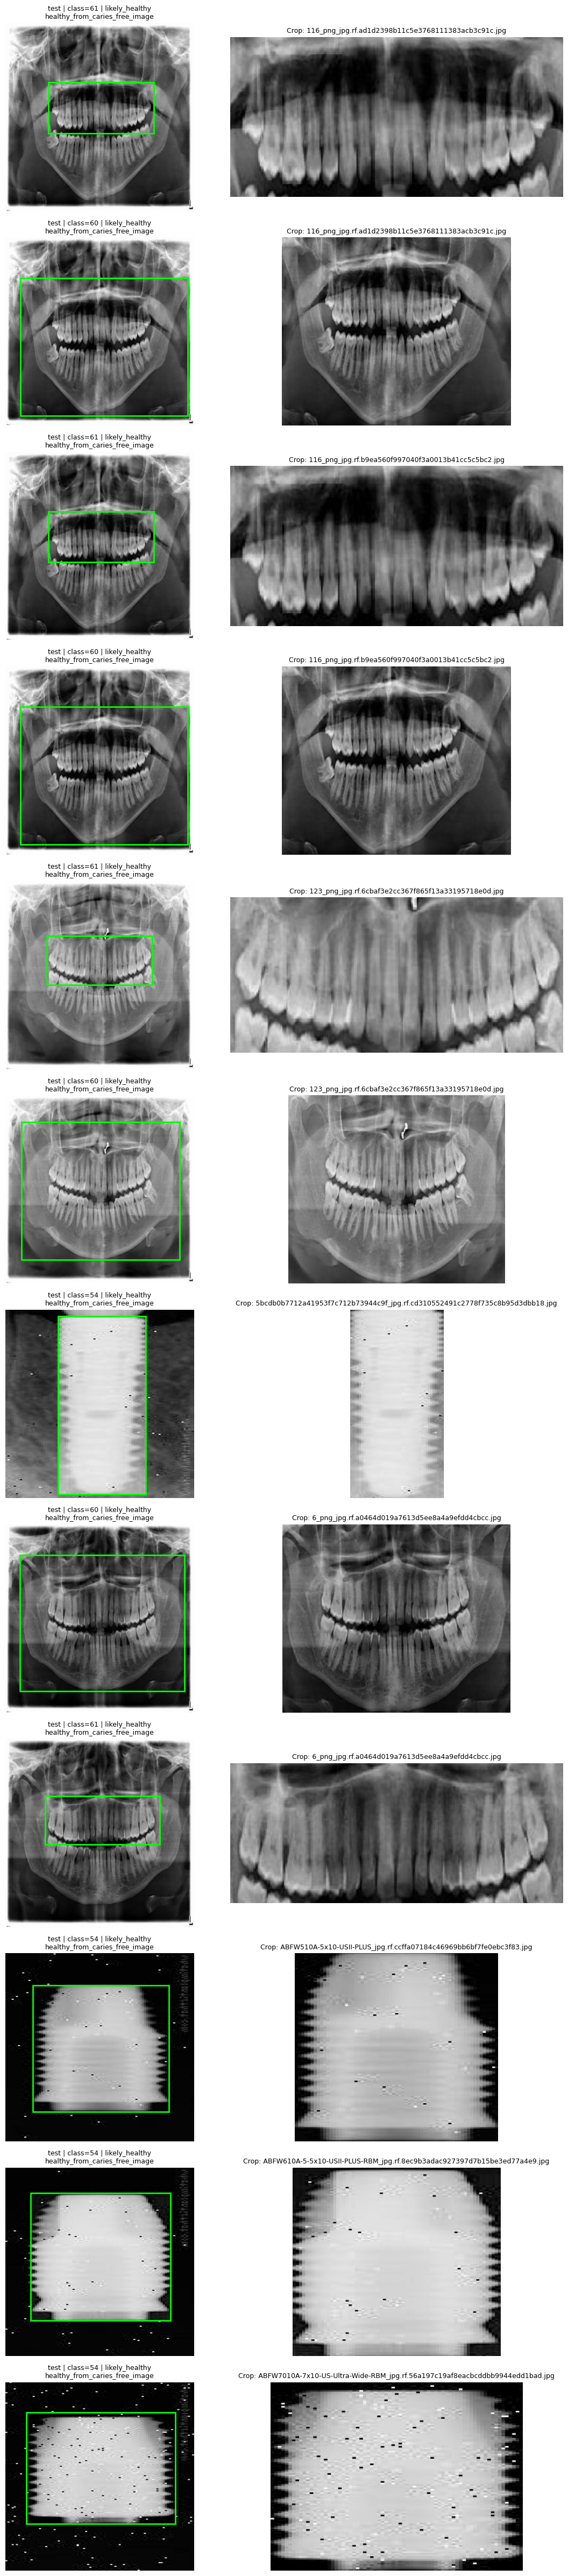

In [24]:
# Visualize potential healthy candidates (full image + crop)
import ast
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def _resolve_classification_image_path(split: str, file_name: str) -> Path:
    p = Path(file_name)
    if p.exists():
        return p
    return Path('/work/scripts/data/classification') / split / file_name

def _parse_bbox_xywh(v):
    if isinstance(v, str):
        try:
            v = ast.literal_eval(v)
        except Exception:
            return None
    if not isinstance(v, (list, tuple)) or len(v) != 4:
        return None
    try:
        x, y, w, h = [float(t) for t in v]
    except Exception:
        return None
    return [x, y, w, h]

def _unique_candidate_rows(df):
    tmp = df.copy()
    tmp['bbox_key'] = tmp['tooth_bbox_xywh'].astype(str)
    return tmp.drop_duplicates(subset=['split', 'image_id', 'tooth_class_name', 'bbox_key']).reset_index(drop=True)

vis_source = _unique_candidate_rows(candidate_view)
n_show = min(12, len(vis_source))
sample_vis = vis_source.head(n_show)

print('Displaying candidates:', n_show)

if n_show == 0:
    print('No candidates to display.')
else:
    fig, axes = plt.subplots(n_show, 2, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = [axes]

    for i, (_, row) in enumerate(sample_vis.iterrows()):
        split = str(row['split'])
        file_name = str(row['file_name'])
        bbox_xywh = _parse_bbox_xywh(row['tooth_bbox_xywh'])
        img_path = _resolve_classification_image_path(split, file_name)

        ax_full = axes[i][0]
        ax_crop = axes[i][1]

        if (not img_path.exists()) or (bbox_xywh is None):
            ax_full.text(0.5, 0.5, f'Missing image or bbox\n{img_path}', ha='center', va='center')
            ax_full.axis('off')
            ax_crop.axis('off')
            continue

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        x, y, w, h = bbox_xywh

        x1 = max(0, int(round(x)))
        y1 = max(0, int(round(y)))
        x2 = min(img_w, int(round(x + w)))
        y2 = min(img_h, int(round(y + h)))

        ax_full.imshow(img)
        rect = Rectangle((x1, y1), max(1, x2 - x1), max(1, y2 - y1), fill=False, linewidth=2, edgecolor='lime')
        ax_full.add_patch(rect)
        ax_full.set_title(
            f"{split} | class={row['tooth_class_name']} | {row['strict_status']}\n{row['proposed_status']}",
            fontsize=9
        )
        ax_full.axis('off')

        crop = img.crop((x1, y1, x2, y2))
        ax_crop.imshow(crop)
        ax_crop.set_title(f'Crop: {file_name}', fontsize=9)
        ax_crop.axis('off')

    plt.tight_layout()
    plt.show()

Candidate rows with valid geometry: 28713
Tooth-like candidates after filtering: 1898


,split,image_id,file_name,tooth_class_name,strict_status,proposed_status,bbox_area_ratio,bbox_width_ratio,bbox_height_ratio
0,train,5577,1350830000-jpg_png_jpg.rf.1bd88603021d944148e2...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005000,0.050000,0.100000
1,train,994,3980220000-jpg_png_jpg.rf.1be9bd0d59c7f7468149...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005000,0.057405,0.087108
2,valid,302,4059790000-jpg_png_jpg.rf.fd8f31054acf4965895d...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005000,0.057405,0.087108
3,train,4617,3944810000-jpg_png_jpg.rf.2af5a14ecd2a6a4d2be2...,73,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005001,0.049505,0.101017
4,test,62,4051070000-jpg_png_jpg.rf.fba0b7a0226b6fabb75f...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005001,0.048169,0.103833
5,test,704,3876200000-jpg_png_jpg.rf.9fbcf1f8e6ca7f43cfda...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005003,0.055516,0.090116
6,train,4410,4077270000-jpg_png_jpg.rf.b3d8bd3f8eb69342d70a...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005003,0.055516,0.090116
7,train,4225,4052400000-jpg_png_jpg.rf.9506f3429a1ca03ab0d8...,73,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005004,0.047555,0.105227
8,test,295,3665670000-jpg_png_jpg.rf.2393dd67f10ddb7bb597...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005005,0.064719,0.077333
9,train,5231,3869800000-jpg_png_jpg.rf.884c1b18f085d380a7a1...,52,likely_unhealthy_context,healthy_candidate_zero_overlap,0.005006,0.056931,0.087936


Displaying filtered candidates: 12


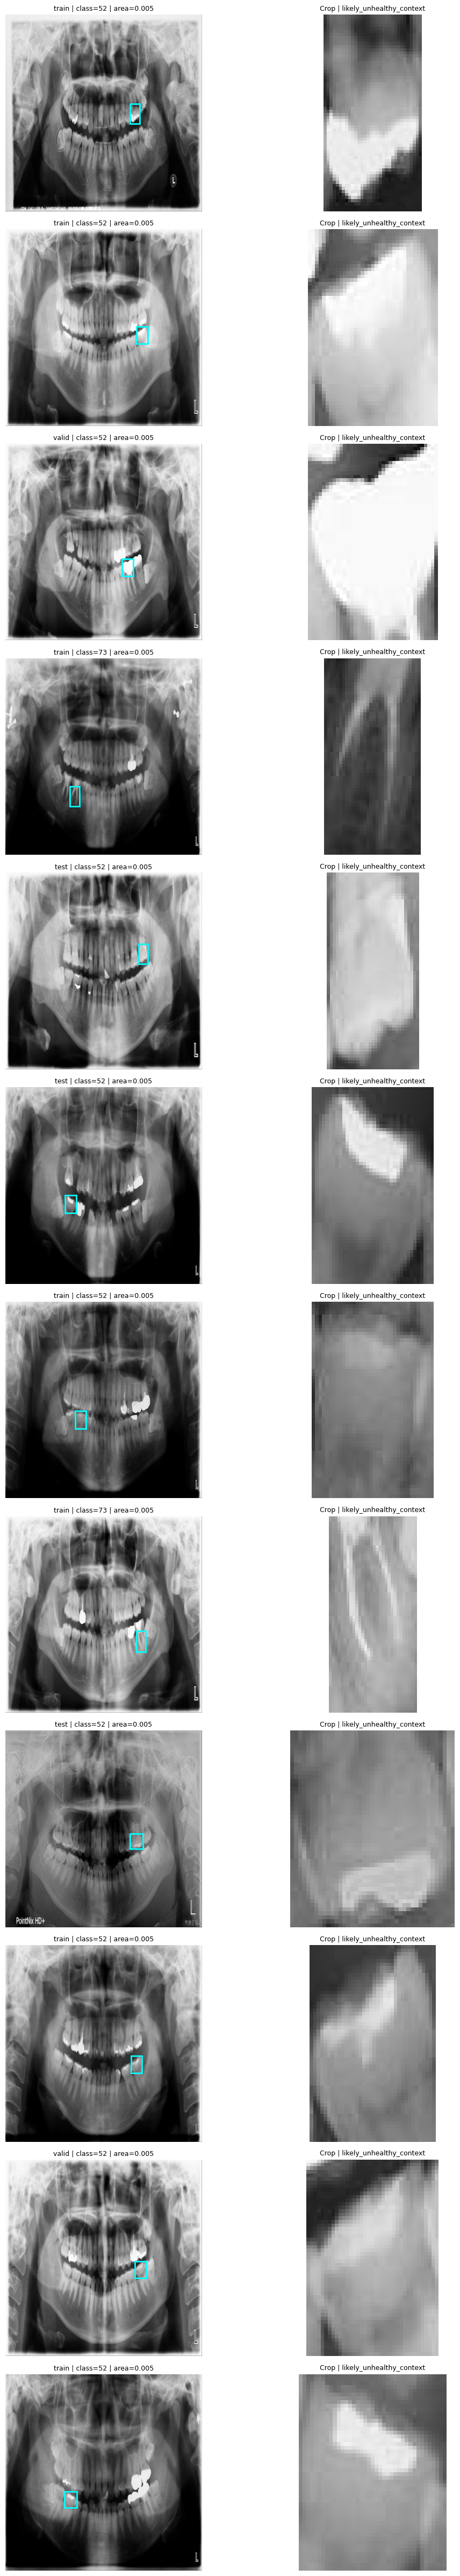

In [25]:
# Filter out full-jaw / implant-like boxes and visualize tooth-like candidates only
import ast
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def _parse_bbox(v):
    if isinstance(v, str):
        try:
            v = ast.literal_eval(v)
        except Exception:
            return None
    if not isinstance(v, (list, tuple)) or len(v) != 4:
        return None
    try:
        x, y, w, h = [float(t) for t in v]
    except Exception:
        return None
    if w <= 1 or h <= 1:
        return None
    return [x, y, w, h]

# Build image dimension lookup for classification dataset
cls_dim_lookup = {}
for _, r in cls_img_df.iterrows():
    cls_dim_lookup[(str(r['split']), str(r['file_name']))] = (int(r['width']), int(r['height']))

def _unique_rows(df):
    tmp = df.copy()
    tmp['bbox_key'] = tmp['tooth_bbox_xywh'].astype(str)
    return tmp.drop_duplicates(subset=['split', 'image_id', 'file_name', 'tooth_class_name', 'bbox_key']).reset_index(drop=True)

base = _unique_rows(candidate_view)

# Compute geometry features for filtering
geom_rows = []
for _, row in base.iterrows():
    key = (str(row['split']), str(row['file_name']))
    dims = cls_dim_lookup.get(key)
    bbox = _parse_bbox(row['tooth_bbox_xywh'])
    if dims is None or bbox is None:
        continue
    img_w, img_h = dims
    x, y, w, h = bbox
    area_ratio = (w * h) / max(1.0, float(img_w * img_h))
    width_ratio = w / max(1.0, float(img_w))
    height_ratio = h / max(1.0, float(img_h))
    aspect = w / max(1.0, h)
    geom_rows.append({
        **row.to_dict(),
        'img_w': img_w,
        'img_h': img_h,
        'bbox_x': x,
        'bbox_y': y,
        'bbox_w': w,
        'bbox_h': h,
        'bbox_area_ratio': area_ratio,
        'bbox_width_ratio': width_ratio,
        'bbox_height_ratio': height_ratio,
        'bbox_aspect': aspect,
    })

geom_df = pd.DataFrame(geom_rows)
print('Candidate rows with valid geometry:', len(geom_df))

# Heuristic tooth-like filter (exclude jaw-wide / very tall / giant regions)
filtered = geom_df[
    (geom_df['bbox_area_ratio'] >= 0.005)
    & (geom_df['bbox_area_ratio'] <= 0.20)
    & (geom_df['bbox_width_ratio'] <= 0.70)
    & (geom_df['bbox_height_ratio'] <= 0.55)
    & (geom_df['bbox_aspect'] >= 0.35)
    & (geom_df['bbox_aspect'] <= 4.0)
]
filtered = filtered.sort_values(['bbox_area_ratio', 'split', 'file_name']).reset_index(drop=True)

print('Tooth-like candidates after filtering:', len(filtered))
display(filtered[['split', 'image_id', 'file_name', 'tooth_class_name', 'strict_status', 'proposed_status', 'bbox_area_ratio', 'bbox_width_ratio', 'bbox_height_ratio']].head(30))

# Visualize filtered candidates
n_show = min(12, len(filtered))
print('Displaying filtered candidates:', n_show)

if n_show == 0:
    print('No filtered candidates found. Consider relaxing thresholds.')
else:
    fig, axes = plt.subplots(n_show, 2, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        row = filtered.iloc[i]
        split = str(row['split'])
        file_name = str(row['file_name'])
        img_path = _resolve_classification_image_path(split, file_name)

        ax_full = axes[i][0]
        ax_crop = axes[i][1]

        if not img_path.exists():
            ax_full.text(0.5, 0.5, f'Missing image\n{img_path}', ha='center', va='center')
            ax_full.axis('off')
            ax_crop.axis('off')
            continue

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        x1 = max(0, int(round(row['bbox_x'])))
        y1 = max(0, int(round(row['bbox_y'])))
        x2 = min(img_w, int(round(row['bbox_x'] + row['bbox_w'])))
        y2 = min(img_h, int(round(row['bbox_y'] + row['bbox_h'])))

        ax_full.imshow(img)
        rect = Rectangle((x1, y1), max(1, x2 - x1), max(1, y2 - y1), fill=False, linewidth=2, edgecolor='cyan')
        ax_full.add_patch(rect)
        ax_full.set_title(
            f"{split} | class={row['tooth_class_name']} | area={row['bbox_area_ratio']:.3f}",
            fontsize=9
        )
        ax_full.axis('off')

        crop = img.crop((x1, y1, x2, y2))
        ax_crop.imshow(crop)
        ax_crop.set_title(f"Crop | {row['strict_status']}", fontsize=9)
        ax_crop.axis('off')

    plt.tight_layout()
    plt.show()